# 04 · Opening the Black Box — Interpretation and the Road to Deployment

**IUM teaching series, Notebook 4/4** · Wang & Zhao, *Additive Manufacturing*
(2026) 105300.

A sensor you cannot interpret is a sensor you cannot trust. In this notebook:

1. read the network's **attention gates** — does ultrasound actually contribute?
2. rank features per target and check the ranking **matches the physics**;
3. probe **noise robustness**;
4. play with a **virtual sensor dashboard** — and see why this model is the
   feedback signal for closed-loop printing.


### Before we run anything: the setup cell

**Input** — nothing from your side. On Google Colab this cell downloads the
course repository (`github.com/wangyiquan1010-coder/IUM_teaching_colab`), which
ships *all* the data used in this series; running locally, it just finds the
repository folder you already have.

**What this cell does** — clones the repo if needed, moves the working
directory to the repository root (so that every later path like
`data/feature11.csv` resolves), and imports the four things we use everywhere:
`numpy` (signal math), `pandas` (tables), `matplotlib` (plots) and
`ium_utils` — **our own teaching library**, a clean, read-only refactor of the
paper's code that lives in `src/ium_utils.py`. Feel free to open that file at
any point: every function used in the notebooks is defined there, with comments.

**Output** — the imported modules plus a confirmation line printing the
repository root. Nothing is computed yet.


In [1]:
# --- Setup (works both locally and on Google Colab) ---------------------------
# On Colab the notebook starts in an empty machine, so we first download
# ("clone") the whole course repository, which contains the data, the helper
# library and the figures. Locally the files are already next to the notebook,
# so the clone is skipped.
import os, sys

if "google.colab" in sys.modules and not os.path.exists("src"):
    !git clone -q https://github.com/wangyiquan1010-coder/IUM_teaching_colab.git
    %cd IUM_teaching_colab

# Walk up the folder tree until we find the repository root (the folder that
# contains src/). This makes every later path such as "data/feature11.csv"
# work no matter where the notebook was launched from.
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, "src")):
    _parent = os.path.dirname(_here)
    if _parent == _here:
        raise FileNotFoundError("repo root with src/ not found")
    _here = _parent
os.chdir(_here)
sys.path.insert(0, "src")            # so that "import ium_utils" works

import numpy as np                   # arrays / signal math
import pandas as pd                  # tables (features, labels, results)
import matplotlib.pyplot as plt      # static plots
from matplotlib import rc
rc("animation", html="jshtml")       # render animations as interactive players
import ium_utils as iu               # OUR course library (see src/ium_utils.py)
print("setup ok — repo root:", _here)


setup ok — repo root: C:\Users\wangy\Desktop\IUM_teaching_colab


### Rebuilding the dataset table

**Input** — the same two files as Notebook 3: `data/feature11.csv` (the paper's
feature table for all 50 prints) and `data/condition_labels.csv` (the measured
thickness / modulus / DoC). No raw waveforms are needed any more — everything in
this notebook operates on the 344-dimensional representation.

**What this cell does** — reloads and merges the tables exactly as in Notebook 3
(each notebook is self-contained), and stores the list of the 330 layer-wise
column names in `seq_cols` for later reuse.

**Output** — `full` (50 × 344 + labels) and `seq_cols`.


In [2]:
# Same dataset table as Notebook 3 — each notebook runs standalone.
feats = iu.load_features("data/feature11.csv")
labels = iu.load_labels("data/condition_labels.csv")
full = feats.copy()
for c in iu.LABEL_COLS:
    full[c] = labels[c]
seq_cols = iu.seq_columns(full)        # the 330 Layer_{i}_{feature} columns


## 1. What do the attention gates say?

Nothing in this section is copied from the paper. We train a network here, run
it, and read the gate values it actually produces — so the numbers you get are
yours, and they will shift a little with the seed and the hardware.

**Where the gates come from.** The attention gate is four lines of arithmetic
sitting between the branches and the prediction head:

1. each branch turns its input group into a fixed-length vector — part-scale
   statistics → 32 numbers, layer-wise sequence → 128, printing conditions → 16;
2. those are concatenated into one **fusion vector** `x` of length
   32 + 128 + 16 = **176**. This ordering is what makes channels 0–31 "the
   stats branch", 32–159 "the layer-wise branch" and 160–175 "the conditions
   branch";
3. the gate is a small network applied to `x` itself:
   **gate = sigmoid( W₂ · ReLU( W₁ · x ) )**, with `W₁` mapping 176 → 88 and
   `W₂` mapping 88 → 176. The sigmoid forces every one of the 176 outputs into
   (0, 1), so the gate is one weight per channel;
4. the head never sees `x`. It sees **x ⊙ gate**, the fusion vector with each
   channel scaled by its weight.

So a channel with a gate near 1 passes through intact, and one near 0 is
suppressed. Because the gate is computed *from* `x`, it is recomputed for every
sample — the network can weigh its sources differently for different prints.
Reading those weights back is what tells us which branch the model leans on.

---

**Input** — `full`, split by `iu.loio_folds()`; we take fold index 4, so a
**mid-range** exposure intensity is held out.

**What this cell does** — trains one network for that fold, then runs the
forward pass **by hand**, step by step, instead of calling the library: the
three branches, the concatenation, the sigmoid gate, and the gated vector going
into the head. It then checks the by-hand gates against `iu.predict(...,
return_attn=True)` so you can see the two agree.

**Output** — `gates`, an array of (test prints × 176) weights, and the printed
shape check.


In [3]:
import torch

iu.set_seed(42)
folds = list(iu.loio_folds(full))
tr_df, te_df, inten = folds[4]              # hold out a mid-range intensity
a_tr, a_te, sc_y = iu.assemble_arrays(tr_df, te_df)
net = iu.train_model(a_tr, epochs=60)

# ---------------------------------------------------------------------------
# The forward pass, written out. Everything below is also what net(...) does
# internally; we spell it out so the gates are not a black box.
# ---------------------------------------------------------------------------
net.eval()
dev = next(net.parameters()).device
stats = torch.tensor(a_te["stats"]).to(dev)      # (n, 12)  part-scale statistics
seq = torch.tensor(a_te["seq"]).to(dev)          # (n, 30, 11) layer-wise features
proc = torch.tensor(a_te["proc"]).to(dev)        # (n, 2)   layer count, intensity

with torch.no_grad():
    # 1. each branch compresses its input group into a fixed-length vector
    a = net.mlp_s(stats)                                  # -> (n, 32)
    z = net.cnn(seq.permute(0, 2, 1)).permute(0, 2, 1)    # Conv1d across layers
    z, _ = net.lstm(z)                                    # Bi-LSTM across layers
    b = z.max(1).values                                   # max over layers (n, 128)
    c = net.mlp_p(proc)                                   # -> (n, 16)

    # 2. concatenate, in this fixed order -> the fusion vector
    x = torch.cat([a, b, c], dim=1)                       # (n, 176)

    # 3. the gate: sigmoid(W2 @ ReLU(W1 @ x)), one weight in (0,1) per channel.
    #    net.fuse.f is exactly that two-layer MLP, 176 -> 88 -> 176.
    gate = torch.sigmoid(net.fuse.f(x))                   # (n, 176)

    # 4. the prediction head sees the GATED vector, not x itself
    y_scaled = net.head(x * gate)                         # (n, 3), standardised

gates = gate.cpu().numpy()
print("fusion vector:", tuple(x.shape), "  gates:", gates.shape)

# Cross-check: the library's shortcut must give the same gates.
yp, gates_lib = iu.predict(net, a_te, sc_y, return_attn=True)
print("by-hand gates match iu.predict:", np.allclose(gates, gates_lib, atol=1e-5))


fusion vector: (5, 176)   gates: (5, 176)
by-hand gates match iu.predict: True


**Input** — the `gates` array computed above, plus the branch layout.

**What this cell does** — shows every gate value as a heatmap (one row per
held-out print, one column per channel), and averages the gates inside each
branch to compare the three sources.

**Output** — the figure and the per-branch percentages.


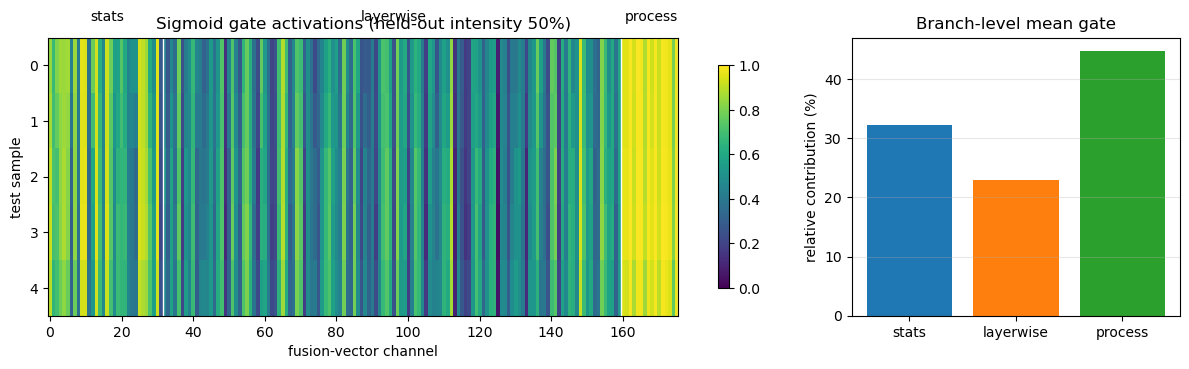

{'stats': '32.2%', 'layerwise': '23.0%', 'process': '44.8%'}


In [4]:
# The fusion vector is the concatenation of the three branch outputs, in this
# fixed order — hence these index ranges.
seg = dict(stats=(0, 32), layerwise=(32, 160), process=(160, 176))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8),
                             gridspec_kw={"width_ratios": [2.4, 1]})
im = a1.imshow(gates, aspect="auto", cmap="viridis", vmin=0, vmax=1)
for name, (lo, hi) in seg.items():
    a1.axvline(hi - 0.5, color="w", lw=1)          # branch boundary
    a1.text((lo + hi) / 2, -0.8, name, ha="center", fontsize=10)
a1.set(xlabel="fusion-vector channel", ylabel="test sample",
       title=f"Sigmoid gate activations (held-out intensity {inten}%)")
plt.colorbar(im, ax=a1, shrink=0.8)

# Average gate per branch, normalised to 100% for a readable relative ranking.
means = {n: float(gates[:, lo:hi].mean()) for n, (lo, hi) in seg.items()}
tot = sum(means.values())
a2.bar(means.keys(), [v / tot * 100 for v in means.values()],
       color=["tab:blue", "tab:orange", "tab:green"])
a2.set(ylabel="relative contribution (%)", title="Branch-level mean gate")
a2.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
print({k: f"{v/tot:.1%}" for k, v in means.items()})


Read the bar chart as the answer to *"does sensing add anything beyond the
recipe?"* — the two ultrasound-derived branches (stats + layer-wise) against
the printing conditions the operator already knows.

> Two honest caveats. First, sigmoid gates are per-channel, not a softmax, so
> they do not sum to anything: turning them into percentages gives a *relative
> ranking*, not shares of a fixed budget. Second, this is one fold and one
> training run; re-run it with a different seed or a different held-out
> intensity and the split moves.

## 2. Feature importance, target by target

A gradient-boosting surrogate gives fast per-target rankings.

---

**Input** — a *collapsed* version of the feature table: instead of 330 columns,
one average per physical descriptor (11 values) plus `layer_count` and
`intensity`. Averaging makes the ranking readable; the crucial detail is that
each print is averaged over its **own** number of layers only, because the
unused layer slots are zero padding and would drag the averages toward zero.

**What this cell does** — fits a gradient-boosting model per target and computes
**permutation importance**: shuffle one column, see how much the prediction
degrades. A feature the model truly relies on hurts a lot when scrambled.

**Output** — three horizontal bar charts (top 8 features per target). Compare
them with the two-scale design in Notebook 2 — the ranking should reproduce the
physics we built in.

> This section is about *interpretation*, so it fits on all 50 samples on
> purpose; it is not a performance claim. Performance numbers only ever come
> from the LOIO protocol.


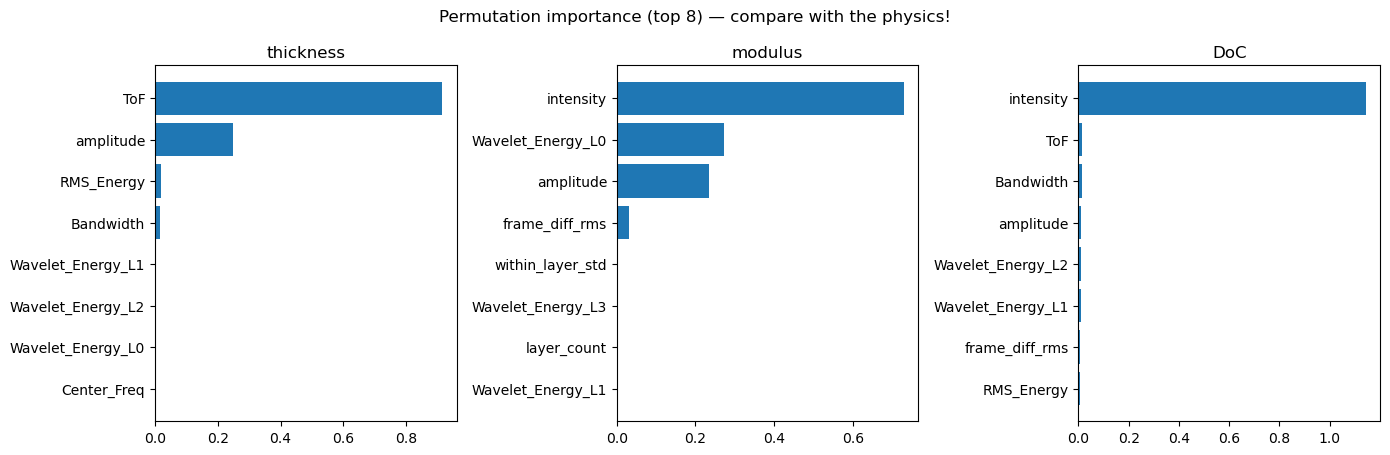

In [5]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# compact, physical feature set: per-feature layer-averages + process + stats
BASES = ["ToF", "amplitude", "RMS_Energy", "Center_Freq", "Bandwidth",
         "Wavelet_Energy_L0", "Wavelet_Energy_L1", "Wavelet_Energy_L2",
         "Wavelet_Energy_L3", "frame_diff_rms", "within_layer_std"]

def collapsed(df):
    """330 layer-wise columns -> 11 per-feature averages (+ the 2 conditions)."""
    out = pd.DataFrame(index=df.index)
    n_real = df.layer.values.astype(int)      # this print's REAL number of layers
    for b in BASES:
        cols = [f"Layer_{i}_{b}" for i in range(1, 31)]
        V = df[cols].values
        # Average over real layers only — slots beyond n are zero padding and
        # would otherwise bias short prints toward zero.
        out[b] = [row[:n].mean() for row, n in zip(V, n_real)]
    out["layer_count"] = df.layer.values
    out["intensity"] = df.intensity.values
    return out

Xc = collapsed(full)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, target in zip(axes, iu.LABEL_COLS):
    m = HistGradientBoostingRegressor(random_state=0).fit(Xc, full[target])
    # Permutation importance: shuffle one column, measure the loss of skill.
    imp = permutation_importance(m, Xc, full[target], n_repeats=10,
                                 random_state=0)
    order = np.argsort(imp.importances_mean)[-8:]        # top 8, ascending
    ax.barh(np.array(Xc.columns)[order], imp.importances_mean[order],
            color="tab:blue")
    ax.set_title(target)
plt.suptitle("Permutation importance (top 8) — compare with the physics!")
plt.tight_layout(); plt.show()


**Check against the two-scale framework:**

- *thickness* ← layer_count and the ToF family (geometry lives in arrival times);
- *modulus* ← spectral features (center frequency / bandwidth — dispersion);
- *DoC* ← within-layer dynamics + intensity (the geometry-immune cure probes).

The model recovered the division of labor the features were designed for.

## 3. How fragile is it? Noise robustness

---

**Input** — the full 344-dimensional `X_all` and the labels `Y`, plus a
per-column magnitude scale so that "5% noise" means the same thing for a ToF in
microseconds and a frequency in hertz.

**What this cell does** — repeats the LOIO evaluation while adding Gaussian
noise to the **test** features only, at several levels, five repetitions each.
Training stays clean on purpose: we are asking "how does a model trained on good
data survive a degraded sensor in the field?", not "does noise help training?".

**Output** — R² versus noise level with error bars. A gentle slope means the
model leans on broad physical trends; a cliff would mean it depends on fragile
details.


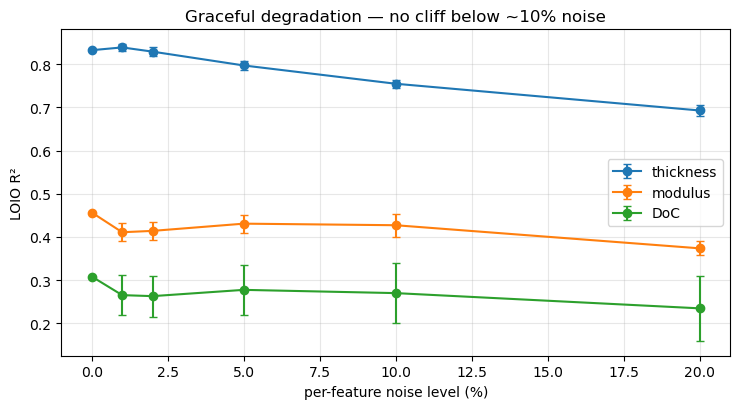

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score

X_all = np.hstack([full[seq_cols + ["layer", "intensity"]].values,
                   iu.part_scale_stats(full).values])
Y = full[iu.LABEL_COLS].values
# Per-column magnitude, so a "5% noise" level is comparable across features
# whose units differ by many orders of magnitude (µs vs Hz vs ratios).
scale = np.abs(X_all).mean(axis=0)

def loio_r2_with_noise(noise_pct, n_rep=5, seed0=0):
    """LOIO R² when the TEST features are corrupted by noise_pct % noise."""
    r2s = []
    for rep in range(n_rep):                      # repeat: noise is random
        rng = np.random.default_rng(seed0 + rep)
        preds = np.zeros_like(Y)
        for tr_idx, te_idx in LeaveOneGroupOut().split(
                X_all, Y, full.intensity.values):
            rf = RandomForestRegressor(200, random_state=0, n_jobs=-1)
            rf.fit(X_all[tr_idx], Y[tr_idx])      # training data stays clean
            Xte = X_all[te_idx] + rng.normal(
                0, noise_pct / 100 * scale, X_all[te_idx].shape)
            preds[te_idx] = rf.predict(Xte)
        r2s.append([r2_score(Y[:, i], preds[:, i]) for i in range(3)])
    return np.array(r2s)                          # (n_rep, 3)

levels = [0, 1, 2, 5, 10, 20]
curves = {l: loio_r2_with_noise(l) for l in levels}

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, l in enumerate(iu.LABEL_COLS):
    mean = [curves[nv][:, i].mean() for nv in levels]
    sd = [curves[nv][:, i].std() for nv in levels]     # spread over repetitions
    ax.errorbar(levels, mean, yerr=sd, marker="o", capsize=3, label=l)
ax.set(xlabel="per-feature noise level (%)", ylabel="LOIO R²",
       title="Graceful degradation — no cliff below ~10% noise")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. The virtual sensor dashboard

Honest out-of-fold predictions for every sample (each was predicted by a model
that never saw its intensity). Pick a condition and compare sensor vs truth —
this is what a *soft sensor* delivers, in real time (2.3–4.7 ms/layer in the
paper's deployment test).

---

**Input** — `X_all` and `Y` again. The cell first computes and caches the
**out-of-fold** predictions for all 50 prints: 10 LOIO folds, each model
predicting only the five prints whose intensity it never saw.

**What this cell does** — after caching, `dashboard()` looks up one print by
(layer count, intensity), and plots measured versus predicted for the three
targets with the relative error. `ipywidgets.interact` turns its two arguments
into dropdowns over the values that actually exist in the design grid.

**Output** — an interactive dashboard. This is the honest version of a sensor
read-out: every number shown comes from a model that had never seen that
exposure intensity, exactly as it would be on a new print.


In [7]:
# Cache out-of-fold RF predictions for all 50 samples (fast enough for a widget).
# Out-of-fold = each sample is predicted by the one model that did NOT train on
# its intensity, so the dashboard cannot flatter itself.
preds = np.zeros_like(Y)
for tr_idx, te_idx in LeaveOneGroupOut().split(X_all, Y, full.intensity.values):
    rf = RandomForestRegressor(300, random_state=0, n_jobs=-1)
    rf.fit(X_all[tr_idx], Y[tr_idx])
    preds[te_idx] = rf.predict(X_all[te_idx])

import ipywidgets as w

def dashboard(layers=15, intensity_pct=70):
    """Show measured vs predicted labels for one print of the design grid."""
    m = (full.layer == layers) & (full.intensity == intensity_pct)
    if not m.any():
        print("no such sample"); return
    i = int(np.where(m)[0][0])
    meas, pred = Y[i], preds[i]              # truth and out-of-fold prediction
    names = ["thickness (mm)", "modulus (Pa)", "DoC (–)"]
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3))
    for ax, n, mv, pv in zip(axes, names, meas, pred):
        ax.bar(["measured", "predicted"], [mv, pv],
               color=["0.4", "tab:green"])
        err = abs(pv - mv) / (abs(mv) + 1e-9) * 100      # relative error, %
        ax.set_title(f"{n}\nerror {err:.1f}%")
    plt.suptitle(f"{layers} layers @ {intensity_pct}% intensity "
                 f"(I = {iu.INTENSITY_MW[intensity_pct]} mW/cm²) — "
                 "prediction from a model that never saw this intensity")
    plt.tight_layout(); plt.show()

# Dropdowns are built from the values that actually exist in the design grid.
w.interact(dashboard, layers=sorted(full.layer.unique()),
           intensity_pct=sorted(full.intensity.unique()));


interactive(children=(Dropdown(description='layers', index=1, options=(np.int64(10), np.int64(15), np.int64(20…

## 5. Where this goes: closing the loop

A validated, fast, interpretable estimate of DoC and thickness **per layer** is
exactly a feedback signal. The authors' ongoing work uses this sensor family
with grayscale exposure as the actuator to close the control loop on the same
printer — toward autonomous, defect-free photopolymer additive manufacturing.

---
*Citation: Wang, Y., & Zhao, X. (2026). Machine learning-aided in-situ
ultrasonic characterization for multi-parametric monitoring of vat
photopolymerization. Additive Manufacturing, 105300.*
